# Quy trình Xử lý và Phân tích Dữ liệu (Data Pipeline)

## Dự án: Nhận diện món ăn Việt Nam (VN-Food Recognition)

Notebook này xây dựng pipeline xử lý dữ liệu cho bài toán **nhận diện món ăn Việt Nam**. Dữ liệu được tổng hợp từ hai nguồn chính:

1. **30VNFoods** - bộ dữ liệu có sẵn về món ăn Việt Nam.
2. **Crawled Data** - dữ liệu ảnh món ăn được nhóm tự crawl bổ sung.

Mục tiêu của notebook là chuẩn hóa nhãn, hợp nhất dữ liệu, kiểm tra chất lượng ảnh, loại bỏ dữ liệu không hợp lệ hoặc trùng lặp, thực hiện phân tích khám phá dữ liệu (EDA), và tạo bộ dữ liệu sạch phục vụ cho các bước huấn luyện mô hình sau này.
### 1. Quy trình thực hiện trong Notebook

Bảng dưới đây tóm tắt các bước chính trong pipeline, từ dữ liệu thô đến dữ liệu sạch phục vụ báo cáo dữ liệu và các bước huấn luyện sau này:

| Task | Mô tả ngắn gọn | Output |
| :--- | :--- | :--- |
| Chuẩn hóa nhãn | Chuẩn hóa tên class từ 30VNFoods và dữ liệu crawl về cùng định dạng `snake_case`; xử lý nhãn rộng/nhãn cụ thể bằng `CLASS_MERGE_MAP`. | Danh sách class chuẩn hóa |
| Hợp nhất dữ liệu | Gộp ảnh từ `data/raw/` và `data/crawled/dataset/raw_images/` theo class chuẩn. | `data/merged/` |
| Tạo manifest | Tạo bảng metadata cho toàn bộ ảnh để phục vụ EDA, kiểm tra chất lượng và truy vết xử lý. | `reports/manifest_*.csv` |
| EDA ban đầu | Thống kê số ảnh theo nguồn/class, phân tích mất cân bằng lớp và đặc tính ảnh như resolution, brightness, blur, file size. | `reports/figures/`, `class_distribution.csv` |
| Kiểm tra & làm sạch dữ liệu | Phát hiện ảnh lỗi, ảnh kém chất lượng, ảnh trùng/gần trùng bằng `imagehash.phash()` và phân loại ảnh sạch/bị loại. | `data/processed/`, `data/rejected/` |
| CLIP filtering | Tùy chọn dùng CLIP zero-shot để phát hiện ảnh không phải đồ ăn sau bước QC cơ bản. | `clip_rejection_log.csv` |
| EDA sau làm sạch | So sánh dữ liệu trước và sau cleaning, thống kê lý do loại ảnh và xác định class còn thiếu dữ liệu. | `rejection_summary.csv`, `shortage_report.csv` |
| Báo cáo tổng kết | Tổng hợp số lượng ảnh, số class, chất lượng dữ liệu, dữ liệu thiếu và cấu trúc lưu trữ cuối cùng. | `reports/final_data_summary.json` |


### 2. Các mục tiêu phân tích chính (EDA)

Notebook này tập trung giải quyết các nội dung cần thiết cho báo cáo dữ liệu:

- **Nguồn và phương pháp thu thập dữ liệu:** Sử dụng dataset có sẵn **30VNFoods** và dữ liệu crawl bổ sung.

- **Quản lý và lưu trữ dữ liệu:** Giữ nguyên dữ liệu gốc, tạo các thư mục `merged/`, `processed/`, `rejected/` và lưu toàn bộ báo cáo trong `reports/`.

- **Chuẩn hóa nhãn:** Chuyển tên class về cùng định dạng và xử lý các trường hợp nhãn rộng/nhãn cụ thể, ví dụ:  
  `pho_bo → pho`, `banh_mi_thit → banh_mi`, `chao_long → chao`.

- **Thống kê mô tả:** Thống kê số lượng ảnh, số class, phân phối dữ liệu theo nguồn và theo từng class.

- **Phân tích mất cân bằng lớp:** Xác định class có quá ít ảnh so với ngưỡng tối thiểu hoặc target ảnh/class.

- **Kiểm tra chất lượng ảnh:** Phân tích độ phân giải, `brightness`, `blur score`, `file size` và `aspect ratio`.

- **Khử trùng lặp:** Sử dụng perceptual hashing (`imagehash.phash`) để phát hiện ảnh trùng hoặc gần trùng về mặt thị giác.

- **Lọc nhiễu:** Xác định ảnh lỗi, ảnh không hợp lệ hoặc ảnh có chất lượng thấp. CLIP zero-shot có thể được dùng như bước lọc ảnh rác bổ sung nếu cần.

- **EDA trước và sau cleaning:** Đánh giá tình trạng dữ liệu ban đầu và mức cải thiện sau khi làm sạch.


## 0. Import & Cấu hình

In [1]:
from google.colab import drive
from pathlib import Path
import shutil
import zipfile

drive.mount('/content/drive')

# ===== 1. DRIVE PATHS =====
DRIVE_PROJECT_ROOT = Path('/content/drive/MyDrive/VietFood-Project')

# Thư mục chứa 2 file zip có sẵn trên Drive
ZIP_30VN = Path('/content/drive/MyDrive/ML_VNFood/data/raw/30VNFoods.zip')
ZIP_CRAWLED = Path('/content/drive/MyDrive/ML_VNFood/data/raw/crawled.zip')

if DRIVE_PROJECT_ROOT.exists():
    print("✓ Đã tìm thấy thư mục dự án trên Drive.")
else:
    print("× Không tìm thấy thư mục dự án:", DRIVE_PROJECT_ROOT)

if not ZIP_30VN.exists():
    raise FileNotFoundError(f"Không tìm thấy file: {ZIP_30VN}")

if not ZIP_CRAWLED.exists():
    raise FileNotFoundError(f"Không tìm thấy file: {ZIP_CRAWLED}")


print("✓ Đã tìm thấy 2 file ZIP dữ liệu trên Drive.")

# ===== 2. LOCAL PATHS ON COLAB SSD =====
PROJECT_ROOT = Path('/content/VietFood-Project')
DATA_DIR = PROJECT_ROOT / 'data'

LOCAL_RAW_DIR = DATA_DIR / 'raw'
LOCAL_DATA_DIR = DATA_DIR

LOCAL_RAW_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

def copy_and_unzip(zip_path: Path, extract_to: Path):
    local_zip = Path('/content') / zip_path.name

    print(f"- Đang copy {zip_path.name} từ Google Drive sang /content...")
    shutil.copy2(zip_path, local_zip)

    print(f"- Đang giải nén {zip_path.name} vào {extract_to}...")
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall(extract_to)

    local_zip.unlink()
    print(f"✓ Hoàn tất xử lý: {zip_path.name}")


# ===== 3. COPY + UNZIP EXISTING ZIP FILES =====
print("- Đang nạp 30VNFoods...")
copy_and_unzip(ZIP_30VN, LOCAL_RAW_DIR)

print("- Đang nạp Crawled Data...")
copy_and_unzip(ZIP_CRAWLED, LOCAL_DATA_DIR)

print("✓ Dữ liệu đã sẵn sàng trên SSD máy ảo.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Đã tìm thấy thư mục dự án trên Drive.
✓ Đã tìm thấy 2 file ZIP dữ liệu trên Drive.
- Đang nạp 30VNFoods...
- Đang copy 30VNFoods.zip từ Google Drive sang /content...
- Đang giải nén 30VNFoods.zip vào /content/VietFood-Project/data/raw...
✓ Hoàn tất xử lý: 30VNFoods.zip
- Đang nạp Crawled Data...
- Đang copy crawled.zip từ Google Drive sang /content...
- Đang giải nén crawled.zip vào /content/VietFood-Project/data...
✓ Hoàn tất xử lý: crawled.zip
✓ Dữ liệu đã sẵn sàng trên SSD máy ảo.


In [2]:
!pip install ImageHash

In [3]:
import os
import hashlib
import cv2
import json
import re
import torch
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from PIL import Image, ImageFile, UnidentifiedImageError
import imagehash
from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel

ImageFile.LOAD_TRUNCATED_IMAGES = True
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

# CẬP NHẬT ĐƯỜNG DẪN THEO VỊ TRÍ TRÊN SSD
RAW_30VN = DATA_DIR / 'raw' / '30VNFoods' / 'Images'
RAW_CRAWLED = DATA_DIR / 'crawled' / 'dataset' / 'raw_images'
RECIPE_DIR = DATA_DIR / 'crawled' / 'recipes'

# THƯ MỤC KẾT QUẢ TRÊN SSD
MERGED_DIR = DATA_DIR / 'merged'
PROCESSED_DIR = DATA_DIR / 'processed'
REJECTED_DIR = DATA_DIR / 'rejected'
REPORT_DIR = PROJECT_ROOT / 'reports'
FIGURE_DIR = REPORT_DIR / 'figures'

for d in [MERGED_DIR, PROCESSED_DIR, REJECTED_DIR, REPORT_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
CLIP_THRESHOLD = 0.25
MIN_IMAGES_PER_CLASS = 100
TARGET_IMAGES_PER_CLASS = 200
MIN_SHORT_SIDE = 400
PHASH_DUPLICATE_DISTANCE = 0  # 0 = trùng pHash y hệt; tăng lên 4-6 nếu muốn bắt near-duplicate mạnh hơn
BLUR_THRESHOLD = 40.0
DARK_THRESHOLD = 35.0
BRIGHT_THRESHOLD = 225.0
MAX_ASPECT_RATIO = 4.0

# TÙY CHỌN XUẤT DỮ LIỆU
COPY_MERGED_IMAGES = True       # Tạo data/merged/<class>/
COPY_PROCESSED_IMAGES = True    # Tạo data/processed/<region>/<food_type>/<class>/ và data/rejected/<reason>/<class>/

# Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(os.path.join(REPORT_DIR, 'pipeline.log'), mode='w'),
    ]
)
log = logging.getLogger(__name__)

print('✓ Import và cấu hình hoàn tất.')
print("RAW_30VN:", RAW_30VN, RAW_30VN.exists())
print("RAW_CRAWLED:", RAW_CRAWLED, RAW_CRAWLED.exists())
print("RECIPE_DIR:", RECIPE_DIR, RECIPE_DIR.exists())
print("REPORT_DIR:", REPORT_DIR)

✓ Import và cấu hình hoàn tất.
RAW_30VN: /content/VietFood-Project/data/raw/30VNFoods/Images True
RAW_CRAWLED: /content/VietFood-Project/data/crawled/dataset/raw_images True
RECIPE_DIR: /content/VietFood-Project/data/crawled/recipes True
REPORT_DIR: /content/VietFood-Project/reports


## 1. Class Map & Ontology

`CLASS_MERGE_MAP` dùng để xử lý trường hợp nhãn cụ thể và nhãn rộng. Ví dụ, trong 30VNFoods class `Pho` có thể gồm phở bò, phở gà, phở heo..., nên `pho_bo` từ dữ liệu crawl được gộp về nhãn rộng `pho` để tránh làm nhiễu class `pho_bo`.

Ontology được thiết kế theo 3 cấp:

- **Cấp 1 - Vùng miền:** `bac`, `trung`, `nam`, `chung`.
- **Cấp 2 - Loại món:** `mon_nuoc`, `mon_kho`, `mon_cuon`, `mon_com`, `banh`, `lau`, `do_an_vat`, `do_uong`.
- **Cấp 3 - Tên món cụ thể:** tên class sau khi chuẩn hóa, ví dụ `pho`, `bun_cha`, `banh_mi`, `com_tam`.

Với các món mơ hồ, nhóm phân loại theo hình thái chính của món trong ảnh và cách ăn phổ biến. Ví dụ, `bun_cha` có nước chấm riêng nhưng thành phần chính là bún ăn kèm chả nướng và rau, nên được xếp vào `mon_kho` thay vì `mon_nuoc`. Tương tự, `mi_quang` có ít nước nhưng không phải món nước dùng chính như phở hoặc bún riêu, nên được xếp vào `mon_kho`.

In [4]:
# ============================================================
# CLASS MERGE MAP
# - key   : tên class sau normalize từ folder gốc
# - value : tên class chuẩn dùng sau khi gộp
# ============================================================

CLASS_MERGE_MAP = {
    "pho_bo": "pho",
    "banh_mi_thit": "banh_mi",
    "chao_long": "chao",
}

# ============================================================
# DISH ONTOLOGY - 3 LEVELS
# ============================================================

DISH_ONTOLOGY = {
    # =========================
    # BẮC
    # =========================
    "pho": ("bac", "mon_nuoc"),
    "bun_cha": ("bac", "mon_kho"),
    "bun_rieu": ("bac", "mon_nuoc"),
    "bun_dau_mam_tom": ("bac", "mon_kho"),
    "banh_chung": ("bac", "banh"),
    "banh_cuon": ("bac", "banh"),
    "banh_duc": ("bac", "banh"),
    "banh_gio": ("bac", "banh"),
    "xoi_xeo": ("bac", "mon_com"),
    "nem_ran": ("bac", "do_an_vat"),

    # =========================
    # TRUNG
    # =========================
    "bun_bo_hue": ("trung", "mon_nuoc"),
    "mi_quang": ("trung", "mon_kho"),
    "cao_lau": ("trung", "mon_kho"),
    "banh_beo": ("trung", "banh"),
    "banh_bot_loc": ("trung", "banh"),
    "banh_can": ("trung", "banh"),
    "com_ga": ("trung", "mon_com"),
    "nem_chua": ("trung", "do_an_vat"),

    # =========================
    # NAM
    # =========================
    "com_tam": ("nam", "mon_com"),
    "com_chien": ("nam", "mon_com"),
    "hu_tieu": ("nam", "mon_nuoc"),
    "bun_mam": ("nam", "mon_nuoc"),
    "bun_thit_nuong": ("nam", "mon_kho"),
    "canh_chua": ("nam", "mon_nuoc"),
    "ca_kho_to": ("nam", "mon_kho"),
    "goi_cuon": ("nam", "mon_cuon"),
    "banh_xeo": ("nam", "banh"),
    "banh_khot": ("nam", "banh"),
    "banh_pia": ("nam", "banh"),
    "banh_tet": ("nam", "banh"),
    "banh_trang_nuong": ("nam", "do_an_vat"),
    "banh_trang_tron": ("nam", "do_an_vat"),
    "sup_cua": ("nam", "mon_nuoc"),
    "xoai_lac": ("nam", "do_an_vat"),
    "lau_thai": ("nam", "lau"),

    # =========================
    # CHUNG / PHỔ BIẾN TOÀN QUỐC
    # =========================
    "banh_bao": ("chung", "banh"),
    "banh_mi": ("chung", "banh"),
    "banh_canh": ("chung", "mon_nuoc"),
    "chao": ("chung", "mon_nuoc"),
    "lau_hai_san": ("chung", "lau"),
    "ga_nuong": ("chung", "mon_kho"),
    "ga_ran": ("chung", "mon_kho"),
    "tra_sua": ("chung", "do_uong"),
}

print(f'✓ Ontology: {len(DISH_ONTOLOGY)} class có mapping vùng miền.')

✓ Ontology: 43 class có mapping vùng miền.


## 2. Hàm hỗ trợ

Các hàm dưới đây được dùng xuyên suốt pipeline:

- **`normalize_name(name)`**
Chuyển tên thư mục (có thể có dấu tiếng Việt, space, gạch ngang) về `snake_case` ASCII, sau đó áp dụng `CLASS_MERGE_MAP`. Ví dụ: `"Phở bò"` → `"pho_bo"` → `"pho"`.

- **`get_region_and_type(dish_key)`**
Tra cứu vùng miền và loại món từ ontology. Trả về `('chung', 'khac')` nếu class chưa được định nghĩa.

- **`get_perceptual_hash(path)`**
Tính **pHash (Perceptual Hash)** dựa trên DCT (Discrete Cosine Transform). Hai ảnh giống nhau về mặt thị giác sẽ cho pHash có Hamming distance nhỏ, ngay cả khi file size hay metadata khác nhau.

- **`image_quality_features(path)`**
Trích xuất đầy đủ metadata kỹ thuật của ảnh. Đặc biệt:

  - **Blur score** - phương sai của Laplacian, đo độ nét của ảnh:

  $$\text{blur_score} = \text{Var}\left(\nabla^2 I\right)$$

  Ảnh nét có phương sai cao (nhiều cạnh rõ); ảnh mờ có phương sai thấp (gradient phẳng).

  - **Aspect ratio** - tỉ lệ cạnh:

  $$\text{aspect_ratio} = \frac{\max(h, w)}{\min(h, w)}$$

In [5]:
def get_region_and_type(dish_key):
    """Tra cứu vùng miền và loại món. Nếu class chưa có trong ontology, trả về ('chung', 'khac')."""
    return DISH_ONTOLOGY.get(dish_key, ('chung', 'khac'))

def normalize_name(name):
    """Tên thư mục -> snake_case ASCII, sau đó apply CLASS_MERGE_MAP."""
    tbl = str.maketrans(
        'àáảãạăắặằẳẵâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ',
        'aaaaaaaaaaaaaaaaaeeeeeeeeeeeiiiiiooooooooooooooooouuuuuuuuuuuyyyyyd'
    )
    name = str(name).lower().translate(tbl)
    name = re.sub(r'[^a-z0-9]+', '_', name).strip('_')
    return CLASS_MERGE_MAP.get(name, name)

def get_perceptual_hash(path: Path):
    """Tính pHash dựa trên DCT bằng thư viện imagehash để phát hiện ảnh trùng/gần trùng trong dữ liệu crawl."""
    try:
        with Image.open(path) as img:
            img = img.convert('RGB')
            return str(imagehash.phash(img))
    except Exception:
        return None

def is_valid_image(path: Path):
    """Kiểm tra ảnh có đọc được và không bị hỏng hay không."""
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

def safe_copy(src: Path, dst: Path):
    """Copy file và tự tạo thư mục đích nếu chưa tồn tại."""
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

def image_quality_features(path: Path):
    """Trích xuất metadata và các chỉ số chất lượng ảnh phục vụ EDA và kiểm soát chất lượng dữ liệu."""
    out = {
        'valid_image': False,
        'width': np.nan,
        'height': np.nan,
        'short_side': np.nan,
        'long_side': np.nan,
        'aspect_ratio': np.nan,
        'brightness_mean': np.nan,
        'brightness_std': np.nan,
        'blur_laplacian_var': np.nan,
        'file_size_kb': np.nan,
        'phash': None,
        'error': None,
    }

    try:
        out['file_size_kb'] = path.stat().st_size / 1024

        with Image.open(path) as img:
            img = img.convert('RGB')
            w, h = img.size

            out['width'] = w
            out['height'] = h
            out['short_side'] = min(w, h)
            out['long_side'] = max(w, h)
            out['aspect_ratio'] = max(w, h) / max(1, min(w, h))
            out['phash'] = str(imagehash.phash(img))

            arr = np.array(img)
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)

            out['brightness_mean'] = float(gray.mean())
            out['brightness_std'] = float(gray.std())
            out['blur_laplacian_var'] = float(cv2.Laplacian(gray, cv2.CV_64F).var())
            out['valid_image'] = True

    except Exception as e:
        out['error'] = str(e)[:300]

    return out

print('✓ Đã định nghĩa các hàm hỗ trợ.')

✓ Đã định nghĩa các hàm hỗ trợ.


## 3. Scan dữ liệu và tạo manifest ban đầu

Bước này đọc hai nguồn dữ liệu ảnh, suy ra class từ cấu trúc thư mục, chuẩn hóa tên class và tạo `manifest_00_index.csv`.

**Manifest** là bảng quản lý trung tâm của dataset: mỗi dòng tương ứng với một ảnh, gồm nguồn dữ liệu, class, đường dẫn và thông tin thư mục gốc. Manifest giúp truy vết quá trình xử lý mà không làm thay đổi dữ liệu gốc.

In [6]:
def scan_folder_dataset(root_dir: Path, source_name: str):
    records = []

    if not root_dir.exists():
        print(f'[CẢNH BÁO] Không tìm thấy thư mục: {root_dir}')
        return records

    # Trường hợp A: root_dir chứa trực tiếp các thư mục class
    # Ví dụ:
    # raw_images/
    # ├── pho/
    # ├── banh_mi/
    # └── com_tam/
    #
    # Trường hợp B: root_dir có cấu trúc lồng train/test/class
    # Ví dụ:
    # Images/
    # ├── Train/
    # │   ├── Pho/
    # │   └── Banh mi/
    # └── Test/
    #     ├── Pho/
    #     └── Banh mi/
    #
    # Khi đó class sẽ được suy ra từ thư mục gần ảnh nhất theo cấu trúc dữ liệu.

    image_paths = [
        p for p in root_dir.rglob('*')
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]

    for path in image_paths:
        rel = path.relative_to(root_dir)
        parts = rel.parts

        # Nếu dạng train/class/image hoặc test/class/image thì lấy class là parts[1]
        if len(parts) >= 3 and parts[0].lower() in {'train', 'val', 'valid', 'validate', 'validation', 'test'}:
            raw_class = parts[1]
            original_split = parts[0].lower()
        else:
            raw_class = parts[0] if len(parts) >= 2 else path.parent.name
            original_split = None

        class_name = normalize_name(raw_class)
        region, food_type = get_region_and_type(class_name)

        records.append({
            'source': source_name,
            'original_split': original_split,
            'raw_class_name': raw_class,
            'class_name': class_name,
            'region': region,
            'food_type': food_type,
            'filename': path.name,
            'suffix': path.suffix.lower(),
            'path': str(path),
            'relative_path': str(rel),
        })

    return records


records = []
records += scan_folder_dataset(RAW_30VN, '30vnfoods')
records += scan_folder_dataset(RAW_CRAWLED, 'crawled')

manifest_index = pd.DataFrame(records)

if manifest_index.empty:
    raise RuntimeError("Không tìm thấy ảnh nào. Hãy kiểm tra lại RAW_30VN và RAW_CRAWLED.")

manifest_index_path = REPORT_DIR / 'manifest_00_index.csv'
manifest_index.to_csv(manifest_index_path, index=False, encoding='utf-8-sig')

print('Tổng số ảnh đã lập chỉ mục:', len(manifest_index))
print('Số class sau chuẩn hóa:', manifest_index['class_name'].nunique())
print('Đã lưu manifest tại:', manifest_index_path)

display(manifest_index.head())

Tổng số ảnh đã lập chỉ mục: 28577
Số class sau chuẩn hóa: 43
Đã lưu manifest tại: /content/VietFood-Project/reports/manifest_00_index.csv


,source,original_split,raw_class_name,class_name,region,food_type,filename,suffix,path,relative_path
0,30vnfoods,validate,Banh tet,banh_tet,nam,banh,579.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/579.jpg,Validate/Banh tet/579.jpg
1,30vnfoods,validate,Banh tet,banh_tet,nam,banh,70.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/70.jpg,Validate/Banh tet/70.jpg
2,30vnfoods,validate,Banh tet,banh_tet,nam,banh,470.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/470.jpg,Validate/Banh tet/470.jpg
3,30vnfoods,validate,Banh tet,banh_tet,nam,banh,281.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/281.jpg,Validate/Banh tet/281.jpg
4,30vnfoods,validate,Banh tet,banh_tet,nam,banh,202.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/202.jpg,Validate/Banh tet/202.jpg


## 4. Trích xuất metadata và chỉ số chất lượng ảnh

Bước này tính các thuộc tính kỹ thuật cho từng ảnh: kích thước, aspect ratio, brightness, blur score, file size và perceptual hash. Đây là dữ liệu nền để thực hiện EDA và phát hiện ảnh không đạt chất lượng.

In [7]:
quality_records = []

for row in tqdm(manifest_index.itertuples(index=False), total=len(manifest_index), desc='Đang trích xuất metadata ảnh'):
    path = Path(row.path)
    q = image_quality_features(path)
    d = row._asdict()
    d.update(q)
    quality_records.append(d)

manifest_all = pd.DataFrame(quality_records)

manifest_all_path = REPORT_DIR / 'manifest_01_all_with_metadata.csv'
manifest_all.to_csv(manifest_all_path, index=False, encoding='utf-8-sig')

print('Đã lưu manifest metadata tại:', manifest_all_path)
display(manifest_all.head())

Đang trích xuất metadata ảnh: 100%|██████████| 28577/28577 [20:29<00:00, 23.24it/s] 


Đã lưu manifest metadata tại: /content/VietFood-Project/reports/manifest_01_all_with_metadata.csv


,source,original_split,raw_class_name,class_name,region,food_type,filename,suffix,path,relative_path,valid_image,width,height,short_side,long_side,aspect_ratio,brightness_mean,brightness_std,blur_laplacian_var,file_size_kb,phash,error
0,30vnfoods,validate,Banh tet,banh_tet,nam,banh,579.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/579.jpg,Validate/Banh tet/579.jpg,True,1080,1080,1080,1080,1.000000,158.935950,56.518451,177.671786,125.991211,d2e22dd478b127ca,None
1,30vnfoods,validate,Banh tet,banh_tet,nam,banh,70.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/70.jpg,Validate/Banh tet/70.jpg,True,450,321,321,450,1.401869,137.035625,70.272060,509.175358,49.416016,beb4f1631488c63d,None
2,30vnfoods,validate,Banh tet,banh_tet,nam,banh,470.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/470.jpg,Validate/Banh tet/470.jpg,True,600,400,400,600,1.500000,132.300458,63.164954,770.165981,89.339844,eaf4c20f85877d06,None
3,30vnfoods,validate,Banh tet,banh_tet,nam,banh,281.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/281.jpg,Validate/Banh tet/281.jpg,True,800,450,450,800,1.777778,123.735769,65.166253,634.700318,272.976562,dec17990c3172573,None
4,30vnfoods,validate,Banh tet,banh_tet,nam,banh,202.jpg,.jpg,/content/VietFood-Project/data/raw/30VNFoods/Images/Validate/Banh tet/202.jpg,Validate/Banh tet/202.jpg,True,640,640,640,640,1.000000,136.104971,62.169282,288.346346,78.261719,cba37de5e0c2c2d0,None


## 5. EDA ban đầu — Trước khi làm sạch

EDA ban đầu mô tả tình trạng dữ liệu gốc sau khi gộp hai nguồn. Mục tiêu:

1. **Phân phối theo nguồn:** Nguồn nào đóng góp bao nhiêu ảnh?
2. **Phân phối theo class:** Class nào nhiều/ít ảnh? Mức độ **class imbalance** ra sao?
3. **Chất lượng ảnh:** Phân bố resolution, brightness, blur score có vấn đề gì không?
4. **Tương quan metadata:** Các thuộc tính kỹ thuật của ảnh có liên hệ với nhau không?
5. **Mẫu ảnh đại diện:** Kiểm tra thực tế nhãn có đúng với nội dung ảnh không.

> **Class imbalance** xảy ra khi số ảnh giữa các class chênh lệch lớn. Điều này khiến model học lệch về class nhiều ảnh và kém chính xác ở class ít ảnh - cần xử lý bằng augmentation hoặc crawl thêm dữ liệu.


### 5.1. Phân phối số lượng ảnh theo nguồn dữ liệu

In [8]:
source_dist = (
    manifest_all
    .groupby('source')
    .size()
    .reset_index(name='n_images')
    .sort_values('n_images', ascending=False)
)

source_dist.to_csv(REPORT_DIR / 'eda_01_source_distribution.csv', index=False, encoding='utf-8-sig')
display(source_dist)

,source,n_images
0,30vnfoods,25136
1,crawled,3441


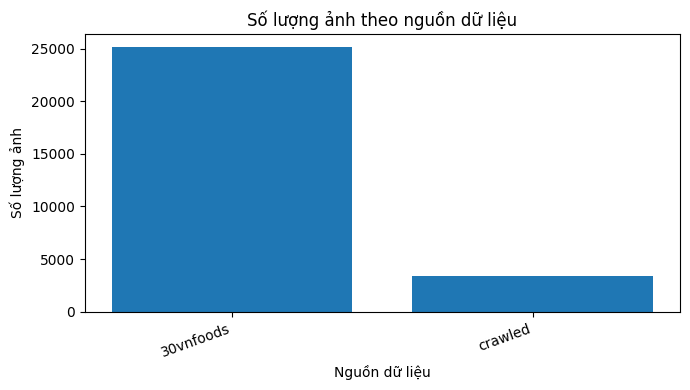

In [9]:

plt.figure(figsize=(7, 4))
plt.bar(source_dist['source'], source_dist['n_images'])
plt.title('Số lượng ảnh theo nguồn dữ liệu')
plt.xlabel('Nguồn dữ liệu')
plt.ylabel('Số lượng ảnh')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_01_source_distribution.png', dpi=300)
plt.show()

**Nhận xét**  
Nguồn 30VNFoods chiếm ưu thế rõ rệt với 25.136 ảnh, trong khi dữ liệu crawled có 3.441 ảnh. Điều này cho thấy dataset chủ yếu dựa trên dữ liệu 30VNFoods, còn ảnh crawled đóng vai trò bổ sung nhằm tăng độ đa dạng. Sự mất cân bằng giữa hai nguồn cần được cân nhắc trong quá trình huấn luyện để hạn chế thiên lệch dữ liệu.

### 5.2. Phân phối số lượng ảnh theo từng class

In [10]:
class_dist = (
    manifest_all
    .groupby('class_name')
    .size()
    .reset_index(name='n_images')
)

class_dist['percent'] = class_dist['n_images'] / class_dist['n_images'].sum() * 100
class_dist = class_dist.sort_values('n_images', ascending=False)

class_dist.to_csv(REPORT_DIR / 'eda_02_class_distribution_before_cleaning.csv', index=False, encoding='utf-8-sig')
display(class_dist)

,class_name,n_images,percent
16,bun_bo_hue,1680,5.878854
10,banh_mi,1393,4.874549
15,banh_xeo,1323,4.629597
20,bun_rieu,1301,4.552612
6,banh_cuon,1290,4.514120
25,chao,1223,4.279665
32,hu_tieu,1133,3.964727
28,com_tam,1042,3.646289
35,mi_quang,1032,3.611296
23,canh_chua,975,3.411835


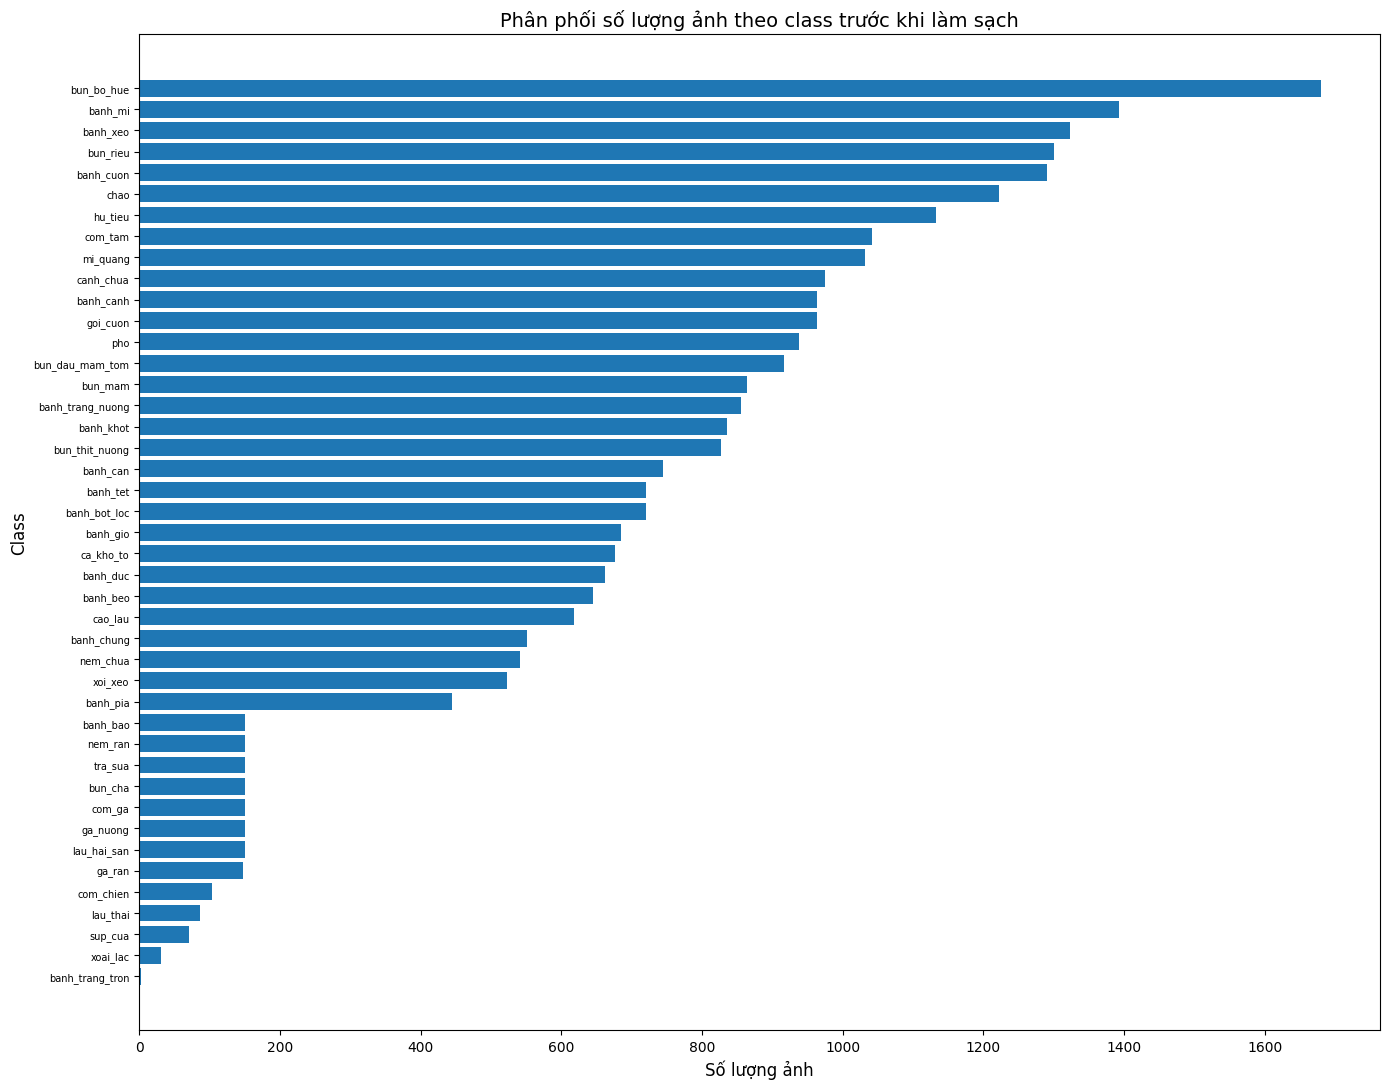

In [11]:
plt.figure(figsize=(14, 11))

plt.barh(class_dist['class_name'], class_dist['n_images'])
plt.gca().invert_yaxis()

plt.title('Phân phối số lượng ảnh theo class trước khi làm sạch', fontsize=14)
plt.xlabel('Số lượng ảnh', fontsize=12)
plt.ylabel('Class', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / 'eda_02_class_distribution_before_cleaning.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

**Nhận xét**  
Phân phối ảnh theo class cho thấy dataset bị mất cân bằng rõ rệt. Class có nhiều ảnh nhất là `bun_bo_hue` với 1.680 ảnh, trong khi class ít nhất là `banh_trang_tron` chỉ có 2 ảnh. Một số class khác như `xoai_lac`, `sup_cua` và `lau_thai` cũng có số lượng ảnh rất thấp. Sự chênh lệch này có thể khiến mô hình thiên về các class có nhiều ảnh, do đó cần bổ sung dữ liệu hoặc áp dụng data augmentation cho các class thiếu ảnh trong giai đoạn huấn luyện.

### 5.3. Thống kê mô tả các chỉ số chất lượng ảnh

In [12]:
numeric_cols = [
    'width', 'height', 'short_side', 'long_side', 'aspect_ratio',
    'brightness_mean', 'brightness_std', 'blur_laplacian_var', 'file_size_kb'
]

quality_stats = manifest_all[numeric_cols].describe().T
quality_stats['median'] = manifest_all[numeric_cols].median(numeric_only=True)
quality_stats['iqr'] = manifest_all[numeric_cols].quantile(0.75) - manifest_all[numeric_cols].quantile(0.25)

quality_stats.to_csv(REPORT_DIR / 'eda_03_image_quality_stats_before_cleaning.csv', encoding='utf-8-sig')
display(quality_stats)

,count,mean,std,min,25%,50%,75%,max,median,iqr
width,28577.0,820.437975,446.867038,100.000000,576.000000,800.000000,1080.000000,7360.000000,800.000000,504.000000
height,28577.0,713.806943,428.441742,83.000000,375.000000,640.000000,1080.000000,5616.000000,640.000000,705.000000
short_side,28577.0,677.771914,381.820891,83.000000,375.000000,640.000000,1079.000000,4912.000000,640.000000,704.000000
long_side,28577.0,856.473003,476.637150,100.000000,576.000000,850.000000,1080.000000,7360.000000,850.000000,504.000000
aspect_ratio,28577.0,1.297405,0.286564,1.000000,1.000000,1.315000,1.500000,4.000000,1.315000,0.500000
brightness_mean,28577.0,133.212966,25.224454,20.295082,117.099369,132.841509,149.474355,242.808249,132.841509,32.374987
brightness_std,28577.0,60.179123,10.136877,17.637822,53.510643,60.017069,66.633456,112.702922,60.017069,13.122813
blur_laplacian_var,28577.0,856.412201,1046.335615,2.858869,244.313541,511.629027,1067.963759,16921.502883,511.629027,823.650218
file_size_kb,28577.0,156.589039,272.015011,3.523438,43.147461,107.278320,180.082031,9515.884766,107.278320,136.934570


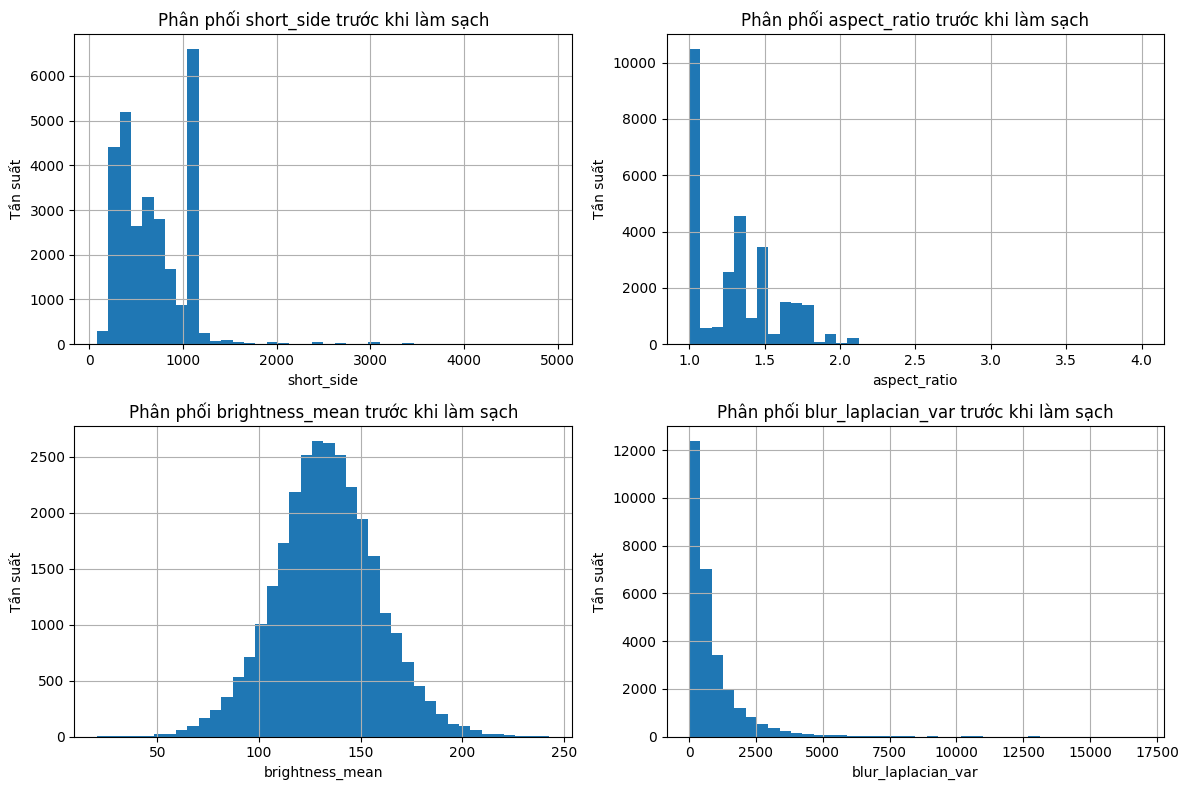

In [13]:
cols = ['short_side', 'aspect_ratio', 'brightness_mean', 'blur_laplacian_var']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    manifest_all[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(f'Phân phối {col} trước khi làm sạch')
    ax.set_xlabel(col)
    ax.set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_03_histograms_before_cleaning_2x2.png', dpi=300)
plt.show()

**Nhận xét**  
Các histogram cho thấy dữ liệu ảnh trước khi làm sạch nhìn chung có chất lượng tương đối ổn. Phần lớn ảnh có kích thước phù hợp, với `short_side` trung bình khoảng 678 px và trung vị 640 px. Tuy nhiên, vẫn tồn tại một số ảnh quá nhỏ hoặc quá lớn, nên cần kiểm soát và chuẩn hóa kích thước trước khi huấn luyện.

Về `aspect_ratio`, đa số ảnh tập trung trong khoảng 1.0-1.5, tức là chủ yếu là ảnh vuông hoặc chữ nhật vừa phải. Tuy vậy, vẫn có một số ảnh có tỉ lệ khung hình bất thường, có thể gây méo ảnh khi resize.

Phân phối `brightness_mean` tập trung quanh 120-150, cho thấy phần lớn ảnh có độ sáng ổn định. Một số ảnh quá tối hoặc quá sáng cần được kiểm tra và loại bỏ nếu vượt ngưỡng chất lượng.

Chỉ số `blur_laplacian_var` có phân phối lệch phải. Điều này cho thấy phần lớn ảnh có độ sắc nét ở mức thấp đến trung bình, trong khi một số ít ảnh rất sắc nét. Những ảnh có giá trị Laplacian variance quá thấp có khả năng bị mờ và cần được loại bỏ.

Tóm lại, dữ liệu ban đầu tương đối phù hợp nhưng vẫn cần bước làm sạch để loại bỏ ảnh quá nhỏ, tỉ lệ bất thường, quá tối/quá sáng hoặc bị mờ trước khi đưa vào huấn luyện mô hình.

### 5.4. Tương quan giữa các thuộc tính số của ảnh

In [14]:
corr = manifest_all[numeric_cols].corr(numeric_only=True)
corr.to_csv(REPORT_DIR / 'eda_04_image_feature_correlation.csv', encoding='utf-8-sig')
display(corr)

,width,height,short_side,long_side,aspect_ratio,brightness_mean,brightness_std,blur_laplacian_var,file_size_kb
width,1.000000,0.851607,0.905966,0.977294,0.133895,-0.040659,0.058680,-0.268982,0.587446
height,0.851607,1.000000,0.974371,0.916760,-0.181384,-0.026618,0.080396,-0.193262,0.546306
short_side,0.905966,0.974371,1.000000,0.924155,-0.209041,-0.021518,0.083542,-0.203592,0.564055
long_side,0.977294,0.916760,0.924155,1.000000,0.129946,-0.044809,0.060359,-0.262810,0.589971
aspect_ratio,0.133895,-0.181384,-0.209041,0.129946,1.000000,-0.046205,-0.025713,-0.231973,-0.025461
brightness_mean,-0.040659,-0.026618,-0.021518,-0.044809,-0.046205,1.000000,-0.160736,-0.016720,-0.028745
brightness_std,0.058680,0.080396,0.083542,0.060359,-0.025713,-0.160736,1.000000,0.149976,0.044513
blur_laplacian_var,-0.268982,-0.193262,-0.203592,-0.262810,-0.231973,-0.016720,0.149976,1.000000,-0.025135
file_size_kb,0.587446,0.546306,0.564055,0.589971,-0.025461,-0.028745,0.044513,-0.025135,1.000000


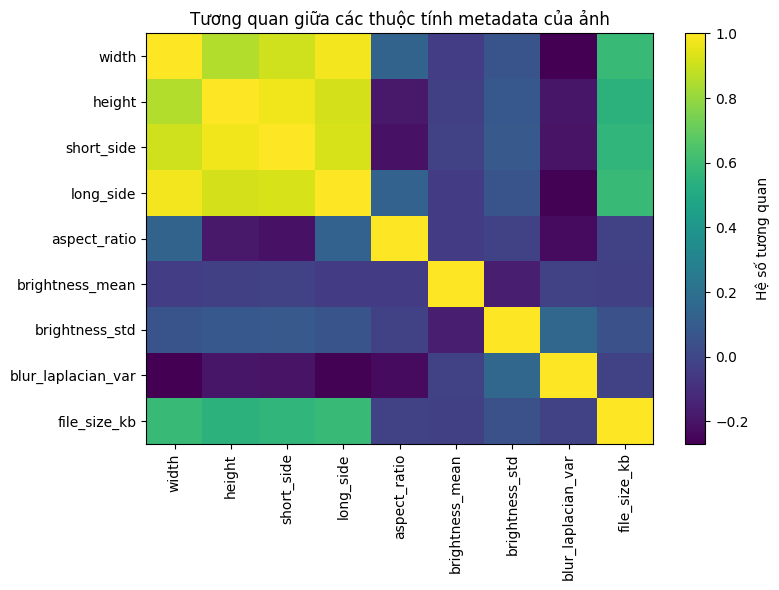

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Hệ số tương quan')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Tương quan giữa các thuộc tính metadata của ảnh')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_04_image_feature_correlation.png', dpi=300)
plt.show()

**Nhận xét**

Ma trận tương quan cho thấy các thuộc tính liên quan đến kích thước ảnh có mối tương quan rất mạnh với nhau. Cụ thể, `width`, `height`, `short_side` và `long_side` đều có hệ số tương quan cao, đặc biệt `width` với `long_side` đạt khoảng 0,98 và `height` với `short_side` đạt khoảng 0,97. Điều này là hợp lý vì các biến này đều mô tả kích thước không gian của ảnh.

`file_size_kb` cũng có tương quan dương ở mức trung bình đến khá với các biến kích thước ảnh, khoảng 0,55-0,59. Điều này cho thấy ảnh có kích thước lớn thường có dung lượng file lớn hơn, tuy nhiên mức tương quan không tuyệt đối vì dung lượng còn phụ thuộc vào định dạng ảnh, mức nén và nội dung ảnh.

`aspect_ratio` có tương quan âm nhẹ với `height` và `short_side`, cho thấy các ảnh có tỉ lệ khung hình lớn hơn thường có xu hướng hẹp hoặc kéo dài hơn theo một chiều. Tuy nhiên, tương quan này không quá mạnh.

Các biến về độ sáng như `brightness_mean` và `brightness_std` gần như không tương quan mạnh với kích thước ảnh hoặc dung lượng file. Điều này cho thấy độ sáng là đặc điểm độc lập tương đối với kích thước ảnh.

Đáng chú ý, `blur_laplacian_var` có tương quan âm nhẹ với các biến kích thước ảnh và `aspect_ratio`. Tuy nhiên, mức tương quan không cao, cho thấy độ mờ/sắc nét của ảnh không phụ thuộc hoàn toàn vào kích thước ảnh mà còn liên quan đến chất lượng chụp, tiêu điểm và nội dung ảnh.

Nhìn chung, ma trận tương quan cho thấy các nhóm biến kích thước có quan hệ chặt chẽ với nhau, trong khi các biến chất lượng ảnh như độ sáng và độ mờ tương đối độc lập. Vì vậy, khi làm sạch dữ liệu, nên sử dụng kết hợp nhiều tiêu chí thay vì chỉ dựa vào một chỉ số duy nhất.

### 5.5. Mẫu ảnh đại diện

In [16]:
SAMPLES_PER_CLASS = 4
MAX_CLASSES_TO_SHOW = 12

sample_rows = (
    manifest_all[manifest_all['valid_image']]
    .groupby('class_name', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

classes = sample_rows['class_name'].unique().tolist()

for cls in classes[:MAX_CLASSES_TO_SHOW]:
    rows = sample_rows[sample_rows['class_name'] == cls]
    n = len(rows)

    plt.figure(figsize=(3 * n, 3))

    for i, (_, r) in enumerate(rows.iterrows(), start=1):
        plt.subplot(1, n, i)

        try:
            img = Image.open(r['path']).convert('RGB')
            plt.imshow(img)
            plt.axis('off')
            plt.title(cls, fontsize=9)
        except Exception:
            plt.axis('off')

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'sample_{cls}.png', dpi=200)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Nhận xét**  
Các mẫu ảnh đại diện cho thấy dataset có nội dung phù hợp với các class món ăn tương ứng. Ảnh có sự đa dạng về góc chụp, ánh sáng, bố cục và cách trình bày món ăn, giúp tăng tính thực tế cho dữ liệu huấn luyện. Tuy nhiên, vẫn có thể xuất hiện một số yếu tố gây nhiễu như nền phức tạp, ánh sáng không đồng đều hoặc vật thể phụ, do đó bước kiểm tra và làm sạch dữ liệu vẫn cần thiết.

## 6. Rule-based Quality Control (QC)

Bước này đánh dấu ảnh không đạt chất lượng theo các tiêu chí rõ ràng và có thể giải thích được - không phụ thuộc vào mô hình.

**Các flag QC và ngưỡng:**

| Flag | Tiêu chí | Ngưỡng |
|------|---------|--------|
| `flag_invalid_image` | Ảnh không mở được hoặc bị corrupt |  |
| `flag_too_small` | Cạnh ngắn quá nhỏ | `short_side < 100px` |
| `flag_extreme_aspect_ratio` | Tỉ lệ cạnh bất thường | `aspect_ratio > 4.0` |
| `flag_too_dark` | Ảnh quá tối | `brightness_mean < 35` |
| `flag_too_bright` | Ảnh quá sáng | `brightness_mean > 225` |
| `flag_blur` | Ảnh mờ | `laplacian_var < 40` |
| `flag_duplicate_phash` | Trùng pHash trong cùng class | Hamming distance = 0 |

**Phát hiện trùng lặp bằng pHash:**

pHash mã hóa nội dung thị giác của ảnh thành chuỗi 64-bit bằng DCT. Khoảng cách Hamming giữa hai pHash đo mức độ khác biệt thị giác:

$$d_{\text{Hamming}}(h_1, h_2) = \sum_{i=1}^{64} \mathbf{1}\left[h_1^{(i)} \neq h_2^{(i)}\right]$$

- $d = 0$: hai ảnh giống hệt nhau về thị giác (exact duplicate).
- $d \leq 4$–$6$: near-duplicate (cùng ảnh, khác nén hoặc khác kích thước nhỏ).

Pipeline dùng `PHASH_DUPLICATE_DISTANCE = 0` - chỉ loại exact duplicate để tránh loại nhầm. Tăng ngưỡng nếu muốn lọc mạnh hơn.

Ảnh bị đánh dấu bởi một hoặc nhiều flag sẽ vào `manifest_rejected`, với `reject_reason` ghi lại tất cả lý do bằng dấu `;`.


In [17]:
df = manifest_all.copy()
MIN_ACCEPTABLE_SHORT_SIDE = 100

# Các cờ kiểm tra cơ bản
df['flag_invalid_image'] = ~df['valid_image'].fillna(False)
df['flag_too_small'] = df['short_side'].fillna(0) < MIN_ACCEPTABLE_SHORT_SIDE
df['flag_extreme_aspect_ratio'] = df['aspect_ratio'].fillna(999) > MAX_ASPECT_RATIO
df['flag_too_dark'] = df['brightness_mean'].fillna(999) < DARK_THRESHOLD
df['flag_too_bright'] = df['brightness_mean'].fillna(0) > BRIGHT_THRESHOLD
df['flag_blur'] = df['blur_laplacian_var'].fillna(999999) < BLUR_THRESHOLD

# Phát hiện ảnh trùng/gần trùng bằng pHash trong cùng một class.
# Mặc định chỉ xem là trùng khi pHash giống hệt nhau để tránh loại nhầm.
# Nếu muốn phát hiện near-duplicate mạnh hơn, có thể mở rộng bằng Hamming distance <= 4 hoặc <= 6.
df['flag_duplicate_phash'] = False

valid_hash = df[df['phash'].notna()].copy()
valid_hash['dup_key'] = valid_hash['class_name'].astype(str) + '::' + valid_hash['phash'].astype(str)

duplicate_mask = valid_hash.duplicated('dup_key', keep='first')
df.loc[valid_hash.index[duplicate_mask], 'flag_duplicate_phash'] = True

flag_cols = [c for c in df.columns if c.startswith('flag_')]

def build_reject_reason(row):
    """Tổng hợp các lý do loại ảnh dựa trên các cờ kiểm tra chất lượng."""
    reasons = [c.replace('flag_', '') for c in flag_cols if bool(row[c])]
    return ';'.join(reasons) if reasons else ''

df['reject_reason'] = df.apply(build_reject_reason, axis=1)
df['is_rejected'] = df['reject_reason'] != ''
df['is_clean'] = ~df['is_rejected']

manifest_clean = df[df['is_clean']].copy()
manifest_rejected = df[df['is_rejected']].copy()

manifest_qc_path = REPORT_DIR / 'manifest_02_qc_flags.csv'
manifest_clean_path = REPORT_DIR / 'manifest_03_clean.csv'
manifest_rejected_path = REPORT_DIR / 'manifest_04_rejected.csv'

df.to_csv(manifest_qc_path, index=False, encoding='utf-8-sig')
manifest_clean.to_csv(manifest_clean_path, index=False, encoding='utf-8-sig')
manifest_rejected.to_csv(manifest_rejected_path, index=False, encoding='utf-8-sig')

print('Đã lưu manifest kèm cờ kiểm tra chất lượng:', manifest_qc_path)
print('Đã lưu manifest ảnh sạch:', manifest_clean_path, '| Số ảnh sạch:', len(manifest_clean))
print('Đã lưu manifest ảnh bị loại:', manifest_rejected_path, '| Số ảnh bị loại:', len(manifest_rejected))

rejection_summary = manifest_rejected['reject_reason'].value_counts().reset_index()
rejection_summary.columns = ['reject_reason', 'n_images']
rejection_summary.to_csv(REPORT_DIR / 'cleaning_01_rejection_summary.csv', index=False, encoding='utf-8-sig')
display(rejection_summary)

Đã lưu manifest kèm cờ kiểm tra chất lượng: /content/VietFood-Project/reports/manifest_02_qc_flags.csv
Đã lưu manifest ảnh sạch: /content/VietFood-Project/reports/manifest_03_clean.csv | Số ảnh sạch: 27869
Đã lưu manifest ảnh bị loại: /content/VietFood-Project/reports/manifest_04_rejected.csv | Số ảnh bị loại: 708


,reject_reason,n_images
0,blur,504
1,duplicate_phash,177
2,too_bright,12
3,too_bright;blur,5
4,too_dark,4
5,blur;duplicate_phash,3
6,too_small,2
7,too_bright;duplicate_phash,1


## 7. Lọc ảnh rác bằng CLIP Zero-shot (Tùy chọn)

CLIP (Contrastive Language-Image Pretraining) được dùng để phát hiện ảnh không phải đồ ăn mà rule-based QC không bắt được - ví dụ: ảnh logo, ảnh người, ảnh nền trắng, ảnh collage.

**Cơ chế hoạt động:**

CLIP tính điểm tương đồng (cosine similarity) giữa image embedding và text embedding của 2 prompt, sau đó dùng softmax để so sánh tương đối:

$$P(\text{food} \mid \text{image}) = \frac{e^{\text{sim}(v, t_{\text{food}})}}{e^{\text{sim}(v, t_{\text{food}})} + e^{\text{sim}(v, t_{\text{non-food}})}}$$

Ảnh có $P(\text{food}) < \text{threshold}$ bị đánh dấu là rác.

**Tại sao đặt CLIP sau rule-based QC?**
- Rule-based loại ảnh lỗi và kém chất lượng trước → CLIP chỉ chạy trên ảnh còn lại → tiết kiệm GPU.
- Rule-based có tiêu chí rõ ràng, không loại nhầm; CLIP có thể loại nhầm nếu threshold chưa phù hợp.

**Mặc định `RUN_CLIP_FILTER = False`** - bật khi có GPU và đã kiểm tra threshold phù hợp với dataset.

In [18]:
RUN_CLIP_FILTER = False   # Đổi thành True nếu muốn chạy CLIP

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_THRESHOLD = 0.25
CLIP_BATCH_SIZE = 32

CLIP_PROMPTS = [
    "a close up photo of delicious vietnamese food",
    "a logo, text, human face, blank image, or random background",
]


def run_clip_filter(manifest_df, threshold=CLIP_THRESHOLD, batch_size=CLIP_BATCH_SIZE):
    """
    Chạy CLIP zero-shot trên manifest_clean tạm thời để phát hiện ảnh rác.

    Output:
    - clip_result: dataframe chứa điểm food_score, non_food_score và quyết định loại ảnh.
    """

    print("=" * 60)
    print("OPTIONAL: Lọc ảnh rác bằng CLIP zero-shot")
    print("=" * 60)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Thiết bị sử dụng: {device}")

    model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
    processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
    model.eval()

    df_clip = manifest_df.copy()
    df_clip = df_clip[df_clip["path"].notna()].copy()

    results = []
    rejected_count = 0

    with torch.no_grad():
        for i in tqdm(range(0, len(df_clip), batch_size), desc="Đang chạy CLIP"):
            batch = df_clip.iloc[i:i + batch_size]

            pil_imgs = []
            valid_rows = []

            for _, row in batch.iterrows():
                try:
                    img = Image.open(row["path"]).convert("RGB")
                    pil_imgs.append(img)
                    valid_rows.append(row)
                except Exception as e:
                    results.append({
                        "path": row["path"],
                        "class_name": row.get("class_name", None),
                        "clip_food_score": None,
                        "clip_non_food_score": None,
                        "clip_is_rejected": True,
                        "clip_reject_reason": f"clip_read_error:{type(e).__name__}",
                    })

            if not pil_imgs:
                continue

            try:
                inputs = processor(
                    text=CLIP_PROMPTS,
                    images=pil_imgs,
                    return_tensors="pt",
                    padding=True
                ).to(device)

                probs = (
                    model(**inputs)
                    .logits_per_image
                    .softmax(dim=1)
                    .detach()
                    .cpu()
                    .numpy()
                )

                for row, prob in zip(valid_rows, probs):
                    food_score = float(prob[0])
                    non_food_score = float(prob[1])

                    clip_is_rejected = food_score < threshold
                    clip_reject_reason = "clip_non_food" if clip_is_rejected else ""

                    if clip_is_rejected:
                        rejected_count += 1

                    results.append({
                        "path": row["path"],
                        "class_name": row["class_name"],
                        "clip_food_score": food_score,
                        "clip_non_food_score": non_food_score,
                        "clip_is_rejected": clip_is_rejected,
                        "clip_reject_reason": clip_reject_reason,
                    })

            except Exception as e:
                for row in valid_rows:
                    results.append({
                        "path": row["path"],
                        "class_name": row["class_name"],
                        "clip_food_score": None,
                        "clip_non_food_score": None,
                        "clip_is_rejected": True,
                        "clip_reject_reason": f"clip_batch_error:{type(e).__name__}",
                    })

    clip_result = pd.DataFrame(results)

    clip_log_path = REPORT_DIR / "clip_rejection_log.csv"
    clip_result.to_csv(clip_log_path, index=False, encoding="utf-8-sig")

    print("\n✓ CLIP filter hoàn tất!")
    print("Số ảnh CLIP đề xuất loại:", rejected_count)
    print("Đã lưu log tại:", clip_log_path)

    return clip_result

In [19]:
if RUN_CLIP_FILTER:
    clip_result = run_clip_filter(manifest_clean, threshold=CLIP_THRESHOLD, batch_size=CLIP_BATCH_SIZE)

    clip_rejected_paths = set(clip_result.loc[clip_result["clip_is_rejected"], "path"].dropna())

    # Ảnh bị CLIP loại: lấy từ clean tạm thời và chuyển sang rejected
    manifest_clip_rejected = manifest_clean[
        manifest_clean["path"].isin(clip_rejected_paths)
    ].copy()

    manifest_clip_rejected["reject_reason"] = "clip_non_food"
    manifest_clip_rejected["is_rejected"] = True
    manifest_clip_rejected["is_clean"] = False

    # Ảnh sạch cuối cùng sau CLIP
    manifest_clean = manifest_clean[~manifest_clean["path"].isin(clip_rejected_paths)].copy()

    # Gộp rejected rule-based + rejected bởi CLIP
    manifest_rejected = pd.concat([manifest_rejected, manifest_clip_rejected], ignore_index=True)

    # Lưu lại manifest sau khi áp dụng CLIP
    manifest_clean.to_csv( REPORT_DIR / "manifest_03_clean.csv", index=False, encoding="utf-8-sig")

    manifest_rejected.to_csv( REPORT_DIR / "manifest_04_rejected.csv", index=False, encoding="utf-8-sig")

    print("✓ Đã áp dụng kết quả CLIP vào manifest.")
    print("Số ảnh sạch cuối cùng:", len(manifest_clean))
    print("Số ảnh bị loại cuối cùng:", len(manifest_rejected))
else:
    print("CLIP filter đang tắt. Kết quả cleaning chỉ dùng rule-based QC.")

CLIP filter đang tắt. Kết quả cleaning chỉ dùng rule-based QC.


## 8. Xuất dữ liệu - Merged, Processed và Rejected

Bước này tạo các thư mục ảnh thực tế từ manifest:

- **`data/merged/<class>/`**
Toàn bộ ảnh từ cả hai nguồn đã chuẩn hóa tên, **chưa qua cleaning**. Dùng để tham chiếu và so sánh với `processed/`.

- **`data/processed/<vung_mien>/<loai_mon>/<ten_mon>/`**
Ảnh sạch sau QC và CLIP (nếu bật), tổ chức theo ontology 3 cấp - chuẩn ImageNet-style. Ảnh có cạnh ngắn < `MIN_SHORT_SIDE` được resize tăng kích thước:

$$\text{scale} = \frac{\text{MIN_SHORT_SIDE}}{\min(h, w)}, \qquad \text{new_size} = \left(\lfloor w \cdot \text{scale} \rceil,\ \lfloor h \cdot \text{scale} \rceil\right)$$

Dùng `INTER_LANCZOS4` để giảm artifact khi phóng to. Tên file có định dạng `<class>_<id>.jpg` đảm bảo unique.

- **`data/rejected/<reason>/<class>/`**
Ảnh bị loại, phân theo lý do đầu tiên để dễ audit. Ví dụ: `rejected/flag_blur/pho/` chứa ảnh phở bị mờ.


In [20]:
def make_output_filename(row, running_id):
    """Tạo tên file đầu ra theo format: class_name_000001.jpg."""
    return f"{row['class_name']}_{running_id:06d}.jpg"


def resize_if_short_side_too_small(src_path: Path, dst_path: Path, min_short_side=MIN_SHORT_SIDE):
    """
    Copy ảnh sang dst_path. Nếu cạnh ngắn nhỏ hơn min_short_side thì resize tăng kích thước.
    Không crop và không normalize mean/std ở bước EDA.
    """
    dst_path.parent.mkdir(parents=True, exist_ok=True)

    img = cv2.imread(str(src_path))

    if img is None:
        raise ValueError(f"Không đọc được ảnh: {src_path}")

    h, w = img.shape[:2]
    short_side = min(h, w)

    if short_side < min_short_side:
        scale = min_short_side / short_side
        new_w = int(round(w * scale))
        new_h = int(round(h * scale))

        img = cv2.resize(
            img,
            (new_w, new_h),
            interpolation=cv2.INTER_LANCZOS4
        )

    cv2.imwrite(
        str(dst_path),
        img,
        [cv2.IMWRITE_JPEG_QUALITY, 95]
    )


# ============================================================
# 1) Copy toàn bộ ảnh đã lập chỉ mục sang merged/<class>/
#    Đây là bản gộp 30VNFoods + crawled, chưa qua cleaning.
# ============================================================

if COPY_MERGED_IMAGES:
    merged_counters = defaultdict(int)
    merged_paths = []

    for _, row in tqdm(
        manifest_all.iterrows(),
        total=len(manifest_all),
        desc='Đang copy ảnh gộp'
    ):
        cls = row['class_name']
        merged_counters[cls] += 1

        out_name = make_output_filename(row, merged_counters[cls])
        dst = MERGED_DIR / cls / out_name

        try:
            safe_copy(Path(row['path']), dst)
            merged_paths.append(str(dst))
        except Exception:
            # Nếu file nguồn lỗi/corrupt thì vẫn giữ trong manifest,
            # nhưng không có đường dẫn copy ở merged_path.
            merged_paths.append(None)

    manifest_all['merged_path'] = merged_paths

    manifest_all.to_csv(
        REPORT_DIR / 'manifest_01_all_with_metadata.csv',
        index=False,
        encoding='utf-8-sig'
    )

    print(f'✓ Đã copy ảnh gộp vào: {MERGED_DIR}')


# ============================================================
# 2) Chuẩn hóa ảnh sạch theo cấu trúc ImageNet-style:
#    processed/<region>/<food_type>/<class_name>/<file>.jpg
#
#    Đồng thời copy ảnh bị loại sang:
#    rejected/<first_reason>/<class_name>/<file>.jpg
# ============================================================

if COPY_PROCESSED_IMAGES:
    processed_counters = defaultdict(int)
    processed_paths = []
    processed_count = 0
    skipped_count = 0

    for _, row in tqdm(
        manifest_clean.iterrows(),
        total=len(manifest_clean),
        desc='Đang chuẩn hóa ảnh sạch'
    ):
        cls = row['class_name']

        region = row.get('region', None)
        food_type = row.get('food_type', None)

        if pd.isna(region) or pd.isna(food_type):
            region, food_type = get_region_and_type(cls)

        region = str(region) if region else 'chung'
        food_type = str(food_type) if food_type else 'unknown'

        processed_counters[cls] += 1
        out_name = make_output_filename(row, processed_counters[cls])
        dst = PROCESSED_DIR / region / food_type / cls / out_name

        try:
            resize_if_short_side_too_small(Path(row['path']), dst, MIN_SHORT_SIDE)
            processed_paths.append(str(dst))
            processed_count += 1
        except Exception:
            processed_paths.append(None)
            skipped_count += 1

    manifest_clean['processed_path'] = processed_paths

    rejected_paths = []
    rejected_counters = defaultdict(int)

    for _, row in tqdm(
        manifest_rejected.iterrows(),
        total=len(manifest_rejected),
        desc='Đang copy ảnh bị loại'
    ):
        cls = row['class_name']
        first_reason = row['reject_reason'].split(';')[0] if row['reject_reason'] else 'unknown'

        rejected_counters[(first_reason, cls)] += 1

        out_name = make_output_filename(row, rejected_counters[(first_reason, cls)])
        dst = REJECTED_DIR / first_reason / cls / out_name

        try:
            safe_copy(Path(row['path']), dst)
            rejected_paths.append(str(dst))
        except Exception:
            rejected_paths.append(None)

    manifest_rejected['rejected_path'] = rejected_paths

    manifest_clean.to_csv(
        REPORT_DIR / 'manifest_03_clean.csv',
        index=False,
        encoding='utf-8-sig'
    )

    manifest_rejected.to_csv(
        REPORT_DIR / 'manifest_04_rejected.csv',
        index=False,
        encoding='utf-8-sig'
    )

    print(f'✓ Đã chuẩn hóa ảnh sạch vào: {PROCESSED_DIR}')
    print(f'  Ảnh đã xử lý thành công: {processed_count}')
    print(f'  Ảnh bỏ qua do lỗi       : {skipped_count}')
    print(f'✓ Đã copy ảnh bị loại vào: {REJECTED_DIR}')

    print('\nCấu trúc processed/:')
    for region_dir in sorted(PROCESSED_DIR.iterdir()):
        if not region_dir.is_dir():
            continue

        for type_dir in sorted(region_dir.iterdir()):
            if not type_dir.is_dir():
                continue

            dishes = [d for d in type_dir.iterdir() if d.is_dir()]
            print(f'  {region_dir.name}/{type_dir.name}/ → {len(dishes)} class')

Đang copy ảnh gộp: 100%|██████████| 28577/28577 [01:39<00:00, 286.38it/s] 


✓ Đã copy ảnh gộp vào: /content/VietFood-Project/data/merged


Đang copy ảnh bị loại: 100%|██████████| 708/708 [00:04<00:00, 160.99it/s]


✓ Đã chuẩn hóa ảnh sạch vào: /content/VietFood-Project/data/processed
  Ảnh đã xử lý thành công: 27869
  Ảnh bỏ qua do lỗi       : 0
✓ Đã copy ảnh bị loại vào: /content/VietFood-Project/data/rejected

Cấu trúc processed/:
  bac/banh/ → 4 class
  bac/do_an_vat/ → 1 class
  bac/mon_com/ → 1 class
  bac/mon_kho/ → 2 class
  bac/mon_nuoc/ → 2 class
  chung/banh/ → 2 class
  chung/do_uong/ → 1 class
  chung/lau/ → 1 class
  chung/mon_kho/ → 2 class
  chung/mon_nuoc/ → 2 class
  nam/banh/ → 4 class
  nam/do_an_vat/ → 3 class
  nam/lau/ → 1 class
  nam/mon_com/ → 2 class
  nam/mon_cuon/ → 1 class
  nam/mon_kho/ → 2 class
  nam/mon_nuoc/ → 4 class
  trung/banh/ → 3 class
  trung/do_an_vat/ → 1 class
  trung/mon_com/ → 1 class
  trung/mon_kho/ → 2 class
  trung/mon_nuoc/ → 1 class


## 9. EDA sau làm sạch và báo cáo thiếu dữ liệu

Sau cleaning, cần đánh giá lại dataset để trả lời:

1. **Class imbalance còn không?** Phân phối class có cân bằng hơn sau khi loại ảnh xấu chưa?
2. **Class nào bị ảnh hưởng nhiều nhất?** Class nào mất nhiều ảnh do QC → cần ưu tiên crawl thêm.
3. **Class nào còn thiếu so với mục tiêu?** Dựa vào `TARGET_IMAGES_PER_CLASS = 200`.

**`shortage_report.csv`** tổng hợp cho mỗi class:

| Cột | Ý nghĩa |
|-----|---------|
| `before_cleaning` | Số ảnh ban đầu |
| `after_cleaning` | Số ảnh sạch còn lại |
| `removed` | Số ảnh bị loại |
| `removed_percent` | Tỉ lệ % bị loại |
| `need_more_images` | Số ảnh cần crawl thêm để đạt target 200 |
| `below_min_threshold` | `True` nếu class có < 100 ảnh |



In [21]:
clean_class_dist = manifest_clean.groupby('class_name').size().reset_index(name='n_images_clean')
clean_class_dist['percent_clean'] = clean_class_dist['n_images_clean'] / clean_class_dist['n_images_clean'].sum() * 100
clean_class_dist = clean_class_dist.sort_values('n_images_clean', ascending=False)

clean_class_dist.to_csv(REPORT_DIR / 'eda_05_class_distribution_after_cleaning.csv', index=False, encoding='utf-8-sig')
display(clean_class_dist)

,class_name,n_images_clean,percent_clean
16,bun_bo_hue,1650,5.920557
10,banh_mi,1348,4.836916
15,banh_xeo,1292,4.635975
20,bun_rieu,1279,4.589329
6,banh_cuon,1243,4.460153
25,chao,1211,4.345330
32,hu_tieu,1113,3.993685
28,com_tam,1021,3.663569
35,mi_quang,997,3.577452
23,canh_chua,954,3.423158


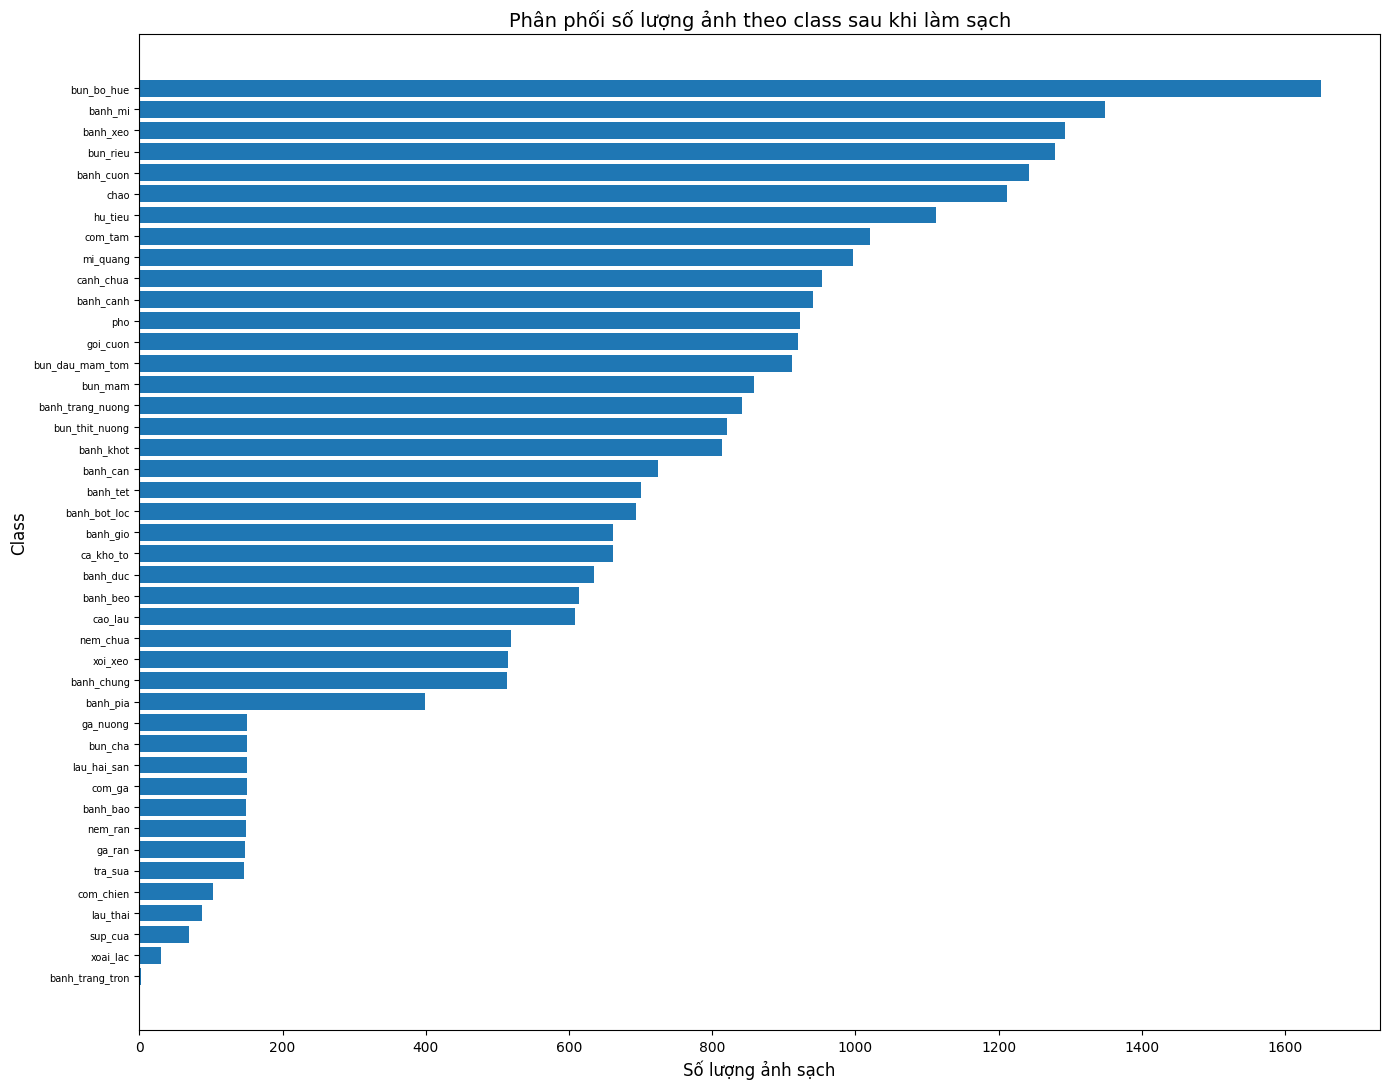

In [22]:
plt.figure(figsize=(14, 11))
plt.barh(clean_class_dist['class_name'], clean_class_dist['n_images_clean'])
plt.gca().invert_yaxis()
plt.title('Phân phối số lượng ảnh theo class sau khi làm sạch', fontsize=14)
plt.xlabel('Số lượng ảnh sạch', fontsize=12)
plt.ylabel('Class', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'eda_05_class_distribution_after_cleaning.png', dpi=300, bbox_inches='tight')
plt.show()

**Nhận xét**  
Sau khi làm sạch, dataset vẫn giữ đủ 43 class. Tuy nhiên, phân phối số lượng ảnh giữa các class vẫn chưa cân bằng. Một số class như `bun_bo_hue`, `banh_mi`, `banh_xeo`, `bun_rieu` và `banh_cuon` có số lượng ảnh lớn, trong khi một số class như `banh_trang_tron`, `xoai_lac`, `sup_cua` và `lau_thai` có số lượng ảnh rất thấp.

Điều này cho thấy quá trình cleaning đã cải thiện chất lượng dữ liệu nhưng chưa giải quyết được vấn đề mất cân bằng class. Do đó, các class ít ảnh cần được ưu tiên bổ sung dữ liệu hoặc áp dụng data augmentation trong giai đoạn huấn luyện.

In [23]:
# So sánh phân phối class trước và sau khi làm sạch
before = class_dist[['class_name', 'n_images']].rename(columns={'n_images': 'before_cleaning'})
after = clean_class_dist[['class_name', 'n_images_clean']].rename(columns={'n_images_clean': 'after_cleaning'})

compare = before.merge(after, on='class_name', how='outer').fillna(0)
compare['removed'] = compare['before_cleaning'] - compare['after_cleaning']
compare['removed_percent'] = np.where(compare['before_cleaning'] > 0, compare['removed'] / compare['before_cleaning'] * 100, 0)
compare = compare.sort_values('after_cleaning', ascending=False)

compare.to_csv(REPORT_DIR / 'eda_06_before_after_cleaning_comparison.csv', index=False, encoding='utf-8-sig')
display(compare)

# Báo cáo các class thiếu dữ liệu so với ngưỡng mục tiêu
shortage = compare.copy()
shortage['target_images'] = TARGET_IMAGES_PER_CLASS
shortage['need_more_images'] = np.maximum(0, TARGET_IMAGES_PER_CLASS - shortage['after_cleaning']).astype(int)
shortage['below_min_threshold'] = shortage['after_cleaning'] < MIN_IMAGES_PER_CLASS

shortage.to_csv(REPORT_DIR / 'shortage_report.csv', index=False, encoding='utf-8-sig')

with open(REPORT_DIR / 'shortage_report.json', 'w', encoding='utf-8') as f:
    json.dump(shortage.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print('Đã lưu báo cáo thiếu dữ liệu:', REPORT_DIR / 'shortage_report.csv')
display(shortage[shortage['below_min_threshold']].sort_values('after_cleaning'))

,class_name,before_cleaning,after_cleaning,removed,removed_percent
16,bun_bo_hue,1680,1650,30,1.785714
10,banh_mi,1393,1348,45,3.230438
15,banh_xeo,1323,1292,31,2.343159
20,bun_rieu,1301,1279,22,1.691007
6,banh_cuon,1290,1243,47,3.643411
25,chao,1223,1211,12,0.981194
32,hu_tieu,1133,1113,20,1.765225
28,com_tam,1042,1021,21,2.015355
35,mi_quang,1032,997,35,3.391473
23,canh_chua,975,954,21,2.153846


Đã lưu báo cáo thiếu dữ liệu: /content/VietFood-Project/reports/shortage_report.csv


,class_name,before_cleaning,after_cleaning,removed,removed_percent,target_images,need_more_images,below_min_threshold
14,banh_trang_tron,2,2,0,0.0,200,198,True
41,xoai_lac,31,31,0,0.0,200,169,True
39,sup_cua,70,70,0,0.0,200,130,True
34,lau_thai,87,87,0,0.0,200,113,True


**Nhận xét**  
Bảng so sánh trước và sau làm sạch cho thấy hầu hết các class chỉ bị loại một tỷ lệ ảnh nhỏ, thường khoảng 1-4%. Điều này cho thấy quá trình cleaning không quá khắt khe và vẫn giữ được phần lớn dữ liệu gốc.

Một số class có tỷ lệ ảnh bị loại cao hơn, như `banh_pia`, `banh_chung`, `banh_beo`, `goi_cuon` và `nem_chua`, nên có thể cần kiểm tra lại chất lượng ảnh ở các nhóm này. Ngoài ra, báo cáo thiếu dữ liệu cho thấy `banh_trang_tron`, `xoai_lac`, `sup_cua` và `lau_thai` vẫn dưới ngưỡng tối thiểu 200 ảnh/class. Vì vậy, các class này cần được ưu tiên bổ sung thêm dữ liệu trong các bước tiếp theo.

## 10. Kiểm tra dữ liệu công thức

Vì hệ thống có hướng mở rộng sang Recipe Engine, notebook kiểm tra sơ bộ thư mục `data/crawled/recipes/` nếu tồn tại.

In [24]:
recipe_rows = []

if RECIPE_DIR.exists():
    recipe_files = sorted([
        p for p in RECIPE_DIR.rglob('*')
        if p.is_file() and p.suffix.lower() == '.csv'
    ])

    for p in recipe_files:
        item = {
            'recipe_file': str(p),
            'file_name': p.name,
            'size_kb': p.stat().st_size / 1024,
            'n_rows': np.nan,
            'n_columns': np.nan,
            'columns': None,
            'error': None,
        }

        try:
            # Đọc CSV
            df_recipe = pd.read_csv(p, encoding='utf-8')

            item['n_rows'] = len(df_recipe)
            item['n_columns'] = df_recipe.shape[1]
            item['columns'] = ', '.join(df_recipe.columns.astype(str).tolist())

        except UnicodeDecodeError:
            try:
                # Phòng trường hợp file CSV bị encoding khác
                df_recipe = pd.read_csv(p, encoding='utf-8-sig')

                item['n_rows'] = len(df_recipe)
                item['n_columns'] = df_recipe.shape[1]
                item['columns'] = ', '.join(df_recipe.columns.astype(str).tolist())

            except Exception as e:
                item['error'] = str(e)[:300]

        except Exception as e:
            item['error'] = str(e)[:300]

        recipe_rows.append(item)

recipe_summary = pd.DataFrame(recipe_rows)

recipe_summary_path = REPORT_DIR / 'recipe_summary.csv'
recipe_summary.to_csv(recipe_summary_path, index=False, encoding='utf-8-sig')

print('Số file recipe CSV:', len(recipe_summary))
print('Đã lưu:', recipe_summary_path)

display(recipe_summary.head())

Số file recipe CSV: 1
Đã lưu: /content/VietFood-Project/reports/recipe_summary.csv


,recipe_file,file_name,size_kb,n_rows,n_columns,columns,error
0,/content/VietFood-Project/data/crawled/recipes/cookpad_recipes.csv,cookpad_recipes.csv,4108.651367,3436,7,"label, ten_mon, url, tieu_de, tac_gia, nguyen_lieu, cach_lam",None


## 11. Lưu trữ và quản lý dữ liệu

Phần này tóm tắt cấu trúc thư mục sau khi pipeline chạy xong.

In [25]:
def folder_tree_counts(base: Path, max_depth=2):
    """Thống kê số lượng file trong các thư mục con để mô tả cấu trúc lưu trữ dữ liệu."""
    rows = []

    for p in sorted(base.rglob('*')):
        if p == base:
            continue

        rel = p.relative_to(base)

        if len(rel.parts) <= max_depth and p.is_dir():
            n_files = sum(1 for x in p.rglob('*') if x.is_file())

            rows.append({
                'folder': str(rel),
                'n_files_recursive': n_files
            })

    return pd.DataFrame(rows)


print('Các thư mục cấp cao trong data/:')

for p in sorted(DATA_DIR.iterdir()):
    if p.is_dir():
        print(' -', p.name)

structure_df = folder_tree_counts(DATA_DIR, max_depth=2)
structure_df.to_csv(REPORT_DIR / 'storage_01_folder_structure_counts.csv', index=False, encoding='utf-8-sig')
display(structure_df)

Các thư mục cấp cao trong data/:
 - crawled
 - merged
 - processed
 - raw
 - rejected


,folder,n_files_recursive
0,crawled,3444
1,crawled/dataset,3441
2,crawled/logs,2
3,crawled/recipes,1
4,merged,28577
...,...,...
56,rejected/blur,507
57,rejected/duplicate_phash,177
58,rejected/too_bright,18
59,rejected/too_dark,4


## 12. Báo cáo tổng kết cuối cùng

In [26]:
summary = {
    'total_indexed_images': int(len(manifest_all)),
    'total_clean_images': int(len(manifest_clean)),
    'total_rejected_images': int(len(manifest_rejected)),
    'n_classes_before_cleaning': int(manifest_all['class_name'].nunique()),
    'n_classes_after_cleaning': int(manifest_clean['class_name'].nunique()),
    'raw_dir': str(RAW_30VN),
    'crawled_raw_dir': str(RAW_CRAWLED),
    'merged_dir': str(MERGED_DIR),
    'processed_dir': str(PROCESSED_DIR),
    'rejected_dir': str(REJECTED_DIR),
    'report_dir': str(REPORT_DIR),
    'duplicate_method': 'imagehash.phash / DCT-based perceptual hashing',
    'split_created': False,
}

with open(REPORT_DIR / 'final_data_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "total_indexed_images": 28577,
  "total_clean_images": 27869,
  "total_rejected_images": 708,
  "n_classes_before_cleaning": 43,
  "n_classes_after_cleaning": 43,
  "raw_dir": "/content/VietFood-Project/data/raw/30VNFoods/Images",
  "crawled_raw_dir": "/content/VietFood-Project/data/crawled/dataset/raw_images",
  "merged_dir": "/content/VietFood-Project/data/merged",
  "processed_dir": "/content/VietFood-Project/data/processed",
  "rejected_dir": "/content/VietFood-Project/data/rejected",
  "report_dir": "/content/VietFood-Project/reports",
  "duplicate_method": "imagehash.phash / DCT-based perceptual hashing",
  "split_created": false
}


## 13. Lưu kết quả

In [27]:
# ============================================================
# BACKUP FINAL OUTPUTS TO GOOGLE DRIVE
# Tạo thư mục quan trọng + lưu kết quả processed/rejected/merged/reports
# ============================================================

# 1. Đường dẫn project local trên Colab
PROJECT_ROOT = Path('/content/VietFood-Project')

# 2. Đường dẫn project trên Google Drive
DRIVE_PROJECT_ROOT = Path('/content/drive/MyDrive/VietFood-Project')

# 3. Tạo các thư mục quan trọng trên Drive
important_drive_dirs = [
    DRIVE_PROJECT_ROOT,
    DRIVE_PROJECT_ROOT / 'data',
    DRIVE_PROJECT_ROOT / 'data' / 'raw',
    DRIVE_PROJECT_ROOT / 'data' / 'crawled',
    DRIVE_PROJECT_ROOT / 'data' / 'merged',
    DRIVE_PROJECT_ROOT / 'data' / 'processed',
    DRIVE_PROJECT_ROOT / 'data' / 'rejected',
    DRIVE_PROJECT_ROOT / 'reports',
    DRIVE_PROJECT_ROOT / 'reports' / 'figures',
]

print('Đang tạo cấu trúc thư mục trên Google Drive...')

for d in important_drive_dirs:
    d.mkdir(parents=True, exist_ok=True)
    print(f'Đã tạo/đã tồn tại: {d}')

# 4. Copy các thư mục output quan trọng từ local về Drive
folders_to_backup = [
    'data/processed',
    'data/rejected',
    'data/merged',
    'reports'
]

print('\nĐang lưu kết quả về Google Drive...')

for folder in folders_to_backup:
    src = PROJECT_ROOT / folder
    dst = DRIVE_PROJECT_ROOT / folder

    if src.exists():
        if dst.exists():
            shutil.rmtree(dst)

        shutil.copytree(src, dst)
        print(f'Đã lưu: {src} -> {dst}')
    else:
        print(f'Không tìm thấy, bỏ qua: {src}')

print('\nHoàn tất backup kết quả về Google Drive.')
print('Vị trí lưu:', DRIVE_PROJECT_ROOT)

Đang tạo cấu trúc thư mục trên Google Drive...
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/data
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/data/raw
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/data/crawled
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/data/merged
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/data/processed
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/data/rejected
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/reports
Đã tạo/đã tồn tại: /content/drive/MyDrive/VietFood-Project/reports/figures

Đang lưu kết quả về Google Drive...
Đã lưu: /content/VietFood-Project/data/processed -> /content/drive/MyDrive/VietFood-Project/data/processed
Đã lưu: /content/VietFood-Project/data/rejected -> /content/drive/MyDrive/VietFood-Project/data/rejected
Đã lưu: /content/VietFood-Project/data/merged -> /content/drive/MyDrive/VietFood-